# Predicting Dengue Outbreaks from Urban Environmental Conditions in RS/BRA

## 0. Problem definition

Dengue fever remains a major public health burden in Brazil, with epidemic cycles driven by complex interactions between climate, urban infrastructure, and the biology of the *Aedes aegypti* mosquito that transmits the virus.

This project investigates whether **weekly dengue outbreak events** in Rio Grande do Sul municipalities can be predicted by combining two categories of environmental signals: meteorological data and sanitation data.

In [1]:
import sys

sys.path.insert(0, '..')  # makes src/ importable from notebooks/

## 1. Data loading

### 1.1 Meteorological Data (INMET) 2020-2024

In [2]:
from src.data.extract import fetch_inmet

inmet = fetch_inmet(years=range(2020, 2024))
print(inmet.shape)
inmet.head(2)

/Users/i554743/Development/cd-trabfinal/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INMET already at: /Users/i554743/Development/cd-trabfinal/notebooks/../data/raw/inmet/inmet_rs_2020_2024.csv
(1748712, 28)


,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),...,"VENTO, VELOCIDADE HORARIA (m/s)",REGIAO,UF,ESTACAO,CODIGO (WMO),LATITUDE,LONGITUDE,ALTITUDE,DATA DE FUNDACAO,year
0,2020/01/01,0000 UTC,0,994,994,"993,3",NaN,"23,9","21,5","24,1",...,"2,3",S,RS,RIO PARDO,A813,-29.0,-52,106,30/09/06,2020
1,2020/01/01,0100 UTC,0,994,"994,1",994,NaN,"24,1","21,1","24,2",...,"2,9",S,RS,RIO PARDO,A813,-29.0,-52,106,30/09/06,2020


### 1.2 IBGE City Codes

In [3]:
from src.data.extract import fetch_rs_geocodes

fetch_rs_geocodes()

IBGE city codes already at: /Users/i554743/Development/cd-trabfinal/notebooks/../data/raw/ibge/rs_city_codes.csv


[{'id': 4300034, 'nome': 'Aceguá'},
 {'id': 4300059, 'nome': 'Água Santa'},
 {'id': 4300109, 'nome': 'Agudo'},
 {'id': 4300208, 'nome': 'Ajuricaba'},
 {'id': 4300307, 'nome': 'Alecrim'},
 {'id': 4300406, 'nome': 'Alegrete'},
 {'id': 4300455, 'nome': 'Alegria'},
 {'id': 4300471, 'nome': 'Almirante Tamandaré do Sul'},
 {'id': 4300505, 'nome': 'Alpestre'},
 {'id': 4300554, 'nome': 'Alto Alegre'},
 {'id': 4300570, 'nome': 'Alto Feliz'},
 {'id': 4300604, 'nome': 'Alvorada'},
 {'id': 4300638, 'nome': 'Amaral Ferrador'},
 {'id': 4300646, 'nome': 'Ametista do Sul'},
 {'id': 4300661, 'nome': 'André da Rocha'},
 {'id': 4300703, 'nome': 'Anta Gorda'},
 {'id': 4300802, 'nome': 'Antônio Prado'},
 {'id': 4300851, 'nome': 'Arambaré'},
 {'id': 4300877, 'nome': 'Araricá'},
 {'id': 4300901, 'nome': 'Aratiba'},
 {'id': 4301008, 'nome': 'Arroio do Meio'},
 {'id': 4301057, 'nome': 'Arroio do Sal'},
 {'id': 4301073, 'nome': 'Arroio do Padre'},
 {'id': 4301107, 'nome': 'Arroio dos Ratos'},
 {'id': 4301206, '

### 1.3 Dengue Cases (Info.Dengue) 2020-2024

In [4]:
from src.data.extract import fetch_dengue

dengue = fetch_dengue()
print(dengue.shape)
dengue.head(2)

InfoDengue already at: /Users/i554743/Development/cd-trabfinal/notebooks/../data/raw/dengue/dengue_rs_2020_2024.csv
(129519, 31)


,data_iniSE,SE,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,Localidade_id,nivel,...,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf,notif_accum_year
0,2020-12-27,202053,0.0,0,0,0,0.5,0.0,0,1,...,56.034705,28.584048,21.729167,29.5,0,NaN,NaN,NaN,NaN,1
1,2020-12-20,202052,0.0,0,0,0,0.0,0.0,0,1,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,1


### 1.4 Sanitation Data (SNIS - SINISA) 2020-2024

In [5]:
from src.data.extract import fetch_cleaned_snis_sinisa

snis_sinisa = fetch_cleaned_snis_sinisa()
print(snis_sinisa.shape)
snis_sinisa.head(2)

Cleaned SNIS/SINISA already at: /Users/i554743/Development/cd-trabfinal/notebooks/../data/raw/residuos/cleaned_snis_sinisa_residuos_2020_2024.csv
(2485, 24)


,RESPONDEU AO MÓDULO DE MANEJO DE RESÍDUOS SÓLIDOS 2023 - Sim/Não,CÓDIGO DO IBGE - Cod_IBGE,MUNICÍPIO - Nom_Mun,Ano de Referência,UF,MACRORREGIÃO - Nom_Região,CAPITAL - Capital,CNPJ - CAD1000,SECRETARIA OU SETOR RESPONSÁVEL - CAD1001,NATUREZA JURÍDICA - CAD1002,...,Quantidade de domicílios urbanos existente no município - OGM4004,Quantidade de domicílios rurais existente no município - OGM4005,Área (Km²) - OGM0005,IRS0001 - Cobertura da população total com coleta de resíduos sólidos domiciliares - Percentual,IRS0002 - Cobertura da população urbana com coleta de resíduos sólidos domiciliares - Percentual,IRS0003 - Cobertura da população rural com coleta de resíduos sólidos domiciliares - Percentual,IRS0004 - Cobertura da população urbana com coleta direta de resíduos sólidos domiciliares - Percentual,IRS0005 - Cobertura da população total com coleta seletiva de resíduos sólidos domiciliares - Percentual,IRS0006 - Cobertura da população urbana com coleta seletiva direta de resíduos sólidos domiciliares - Percentual,RESPONDEU AO MÓDULO DE MANEJO DE RESÍDUOS SÓLIDOS 2024 - Sim/Não
0,Sim,4300034,Aceguá,2020,RS,Sul,NaN,04.217.437/0001-32,Secretaria de Obras e Serviços Públicos,Município,...,515,1629,1551.34,94.99,98.52,93.87,49.26,0.0,0.0,NaN
1,Sim,4300034,Aceguá,2021,RS,Sul,NaN,04.217.437/0001-32,Secretaria de Obras e Serviços Públicos,Município,...,515,1629,1551.34,94.99,98.52,93.87,49.26,0.0,0.0,NaN


## 2. Data Cleaning

In [7]:
from src.data.preprocess import (
    normalize_column_names,
    fix_mojibake,
    normalize_city_name,
    cast_br_numeric_columns,
    cast_sim_nao,
    parse_dates,
    split_categorical_numerical,
)

### 2.1 Meteorological Data

In [9]:
inmet_clean = (
    inmet
    .pipe(normalize_column_names)
    .pipe(cast_br_numeric_columns)
    .pipe(cast_sim_nao)
    .assign(
        data=lambda df: parse_dates(df["data"], fmt="%Y/%m/%d"),
        data_de_fundacao=lambda df: parse_dates(df["data_de_fundacao"], fmt="%d/%m/%y"),
        estacao=lambda df: df["estacao"].str.strip().str.upper(),
    )
)

cat_inmet, num_inmet = split_categorical_numerical(inmet_clean)
print("Shape:", inmet_clean.shape)
print("Categorical columns:", cat_inmet.columns.tolist())
print("Numerical columns:", num_inmet.columns.tolist())
inmet_clean.head(2)

Shape: (1748712, 28)
Categorical columns: ['data', 'hora_utc', 'regiao', 'uf', 'estacao', 'codigo_wmo', 'data_de_fundacao']
Numerical columns: ['precipitacao_total_horario_mm', 'pressao_atmosferica_ao_nivel_da_estacao_horaria_mb', 'pressao_atmosferica_max_na_hora_ant_aut_mb', 'pressao_atmosferica_min_na_hora_ant_aut_mb', 'radiacao_global_kj_m2', 'temperatura_do_ar_bulbo_seco_horaria_c', 'temperatura_do_ponto_de_orvalho_c', 'temperatura_maxima_na_hora_ant_aut_c', 'temperatura_minima_na_hora_ant_aut_c', 'temperatura_orvalho_max_na_hora_ant_aut_c', 'temperatura_orvalho_min_na_hora_ant_aut_c', 'umidade_rel_max_na_hora_ant_aut', 'umidade_rel_min_na_hora_ant_aut', 'umidade_relativa_do_ar_horaria', 'vento_direcao_horaria_gr_gr', 'vento_rajada_maxima_m_s', 'vento_velocidade_horaria_m_s', 'latitude', 'longitude', 'altitude', 'year']


,data,hora_utc,precipitacao_total_horario_mm,pressao_atmosferica_ao_nivel_da_estacao_horaria_mb,pressao_atmosferica_max_na_hora_ant_aut_mb,pressao_atmosferica_min_na_hora_ant_aut_mb,radiacao_global_kj_m2,temperatura_do_ar_bulbo_seco_horaria_c,temperatura_do_ponto_de_orvalho_c,temperatura_maxima_na_hora_ant_aut_c,...,vento_velocidade_horaria_m_s,regiao,uf,estacao,codigo_wmo,latitude,longitude,altitude,data_de_fundacao,year
0,2020-01-01,0000 UTC,0.0,994.0,994.0,993.3,NaN,23.9,21.5,24.1,...,2.3,S,RS,RIO PARDO,A813,-29.0,-52,106,2006-09-30,2020
1,2020-01-01,0100 UTC,0.0,994.0,994.1,994.0,NaN,24.1,21.1,24.2,...,2.9,S,RS,RIO PARDO,A813,-29.0,-52,106,2006-09-30,2020


### 2.2 Dengue Cases

In [10]:
dengue_clean = (
    dengue
    .pipe(normalize_column_names)
    .assign(
        municipio_nome=lambda df: normalize_city_name(fix_mojibake(df["municipio_nome"])),
        data_inise=lambda df: parse_dates(df["data_inise"], fmt="%Y-%m-%d"),
    )
)

cat_dengue, num_dengue = split_categorical_numerical(dengue_clean)
print("Shape:", dengue_clean.shape)
print("Categorical columns:", cat_dengue.columns.tolist())
print("Numerical columns:", num_dengue.columns.tolist())
dengue_clean.head(2)

Shape: (129519, 31)
Categorical columns: ['data_inise', 'versao_modelo', 'municipio_nome']
Numerical columns: ['se', 'casos_est', 'casos_est_min', 'casos_est_max', 'casos', 'p_rt1', 'p_inc100k', 'localidade_id', 'nivel', 'id', 'tweet', 'rt', 'pop', 'tempmin', 'umidmax', 'receptivo', 'transmissao', 'nivel_inc', 'umidmed', 'umidmin', 'tempmed', 'tempmax', 'casprov', 'casprov_est', 'casprov_est_min', 'casprov_est_max', 'casconf', 'notif_accum_year']


,data_inise,se,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,localidade_id,nivel,...,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf,notif_accum_year
0,2020-12-27,202053,0.0,0,0,0,0.5,0.0,0,1,...,56.034705,28.584048,21.729167,29.5,0,NaN,NaN,NaN,NaN,1
1,2020-12-20,202052,0.0,0,0,0,0.0,0.0,0,1,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,1


### 2.3 Sanitation Data

In [13]:
snis_sinisa_clean = (
    snis_sinisa
    .pipe(normalize_column_names)
    .pipe(cast_br_numeric_columns)
    .pipe(cast_sim_nao)
    .assign(
        municipio_nom_mun=lambda df: normalize_city_name(fix_mojibake(df["municipio_nom_mun"]))
    )
)

cat_snis_sinisa, num_snis_sinisa = split_categorical_numerical(snis_sinisa_clean)
print("Shape:", snis_sinisa_clean.shape)
print("Categorical columns:", cat_snis_sinisa.columns.tolist())
print("Numerical columns:", num_snis_sinisa.columns.tolist())
snis_sinisa_clean.head(2)

Shape: (2485, 24)
Categorical columns: ['respondeu_ao_modulo_de_manejo_de_residuos_solidos_2023_sim_nao', 'municipio_nom_mun', 'uf', 'macrorregiao_nom_regiao', 'capital_capital', 'cnpj_cad1000', 'secretaria_ou_setor_responsavel_cad1001', 'natureza_juridica_cad1002', 'respondeu_ao_modulo_de_manejo_de_residuos_solidos_2024_sim_nao']
Numerical columns: ['codigo_do_ibge_cod_ibge', 'ano_de_referencia', 'populacao_total_dfe0001', 'populacao_urbana_dfe0002', 'populacao_rural_dfe0003', 'quantidade_de_domicilios_totais_existente_no_municipio_ogm4006', 'quantidade_de_domicilios_urbanos_existente_no_municipio_ogm4004', 'quantidade_de_domicilios_rurais_existente_no_municipio_ogm4005', 'area_km2_ogm0005', 'irs0001_cobertura_da_populacao_total_com_coleta_de_residuos_solidos_domiciliares_percentual', 'irs0002_cobertura_da_populacao_urbana_com_coleta_de_residuos_solidos_domiciliares_percentual', 'irs0003_cobertura_da_populacao_rural_com_coleta_de_residuos_solidos_domiciliares_percentual', 'irs0004_cob

,respondeu_ao_modulo_de_manejo_de_residuos_solidos_2023_sim_nao,codigo_do_ibge_cod_ibge,municipio_nom_mun,ano_de_referencia,uf,macrorregiao_nom_regiao,capital_capital,cnpj_cad1000,secretaria_ou_setor_responsavel_cad1001,natureza_juridica_cad1002,...,quantidade_de_domicilios_urbanos_existente_no_municipio_ogm4004,quantidade_de_domicilios_rurais_existente_no_municipio_ogm4005,area_km2_ogm0005,irs0001_cobertura_da_populacao_total_com_coleta_de_residuos_solidos_domiciliares_percentual,irs0002_cobertura_da_populacao_urbana_com_coleta_de_residuos_solidos_domiciliares_percentual,irs0003_cobertura_da_populacao_rural_com_coleta_de_residuos_solidos_domiciliares_percentual,irs0004_cobertura_da_populacao_urbana_com_coleta_direta_de_residuos_solidos_domiciliares_percentual,irs0005_cobertura_da_populacao_total_com_coleta_seletiva_de_residuos_solidos_domiciliares_percentual,irs0006_cobertura_da_populacao_urbana_com_coleta_seletiva_direta_de_residuos_solidos_domiciliares_percentual,respondeu_ao_modulo_de_manejo_de_residuos_solidos_2024_sim_nao
0,True,4300034,ACEGUA,2020,RS,Sul,<NA>,04.217.437/0001-32,Secretaria de Obras e Serviços Públicos,Município,...,515,1629,1551.34,94.99,98.52,93.87,49.26,0.0,0.0,<NA>
1,True,4300034,ACEGUA,2021,RS,Sul,<NA>,04.217.437/0001-32,Secretaria de Obras e Serviços Públicos,Município,...,515,1629,1551.34,94.99,98.52,93.87,49.26,0.0,0.0,<NA>


In [14]:
# Remover códigos numéricos dos nomes de colunas e manter apenas colunas com texto legível
snis_sinisa_clean = snis_sinisa_clean.rename(columns=lambda c: c
    .replace('_dfe0001', '')
    .replace('_dfe0002', '')
    .replace('_dfe0003', '')
    .replace('_ogm4006', '')
    .replace('_ogm4004', '')
    .replace('_ogm4005', '')
    .replace('_ogm0005', '')
    .replace('irs0001_cobertura_da_populacao_total_com_coleta_de_residuos_solidos_domiciliares_percentual', 'cobertura_total')
    .replace('irs0002_cobertura_da_populacao_urbana_com_coleta_de_residuos_solidos_domiciliares_percentual', 'cobertura_urbana')
    .replace('irs0003_cobertura_da_populacao_rural_com_coleta_de_residuos_solidos_domiciliares_percentual', 'cobertura_rural')
    .replace('irs0004_cobertura_da_populacao_urbana_com_coleta_direta_de_residuos_solidos_domiciliares_percentual', 'cobertura_urbana_direta')
    .replace('irs0005_cobertura_da_populacao_total_com_coleta_seletiva_de_residuos_solidos_domiciliares_percentual', 'coleta_seletiva_total')
    .replace('irs0006_cobertura_da_populacao_urbana_com_coleta_seletiva_direta_de_residuos_solidos_domiciliares_percentual', 'coleta_seletiva_urbana')
    .replace('municipio_nom_mun', 'municipio')
    .replace('uf', 'estado')
    .replace('codigo_do_ibge_cod_ibge', 'ibge_code')
    .replace('ano_de_referencia', 'year')
    .replace('area_km2', 'area_km2')
    .replace('populacao_total', 'populacao_total')
    .replace('populacao_urbana', 'populacao_urbana')
    .replace('populacao_rural', 'populacao_rural')
    .replace('quantidade_de_domicilios_totais_existente_no_municipio', 'domicilios_totais')
)

cat_cols_to_keep = ['municipio', 'estado']
num_cols_to_keep = [
    'ibge_code',
    'year',
    'area_km2',
    'populacao_total',
    'populacao_urbana',
    'populacao_rural',
    'domicilios_totais',
    'ids',
    'cobertura_total',
    'cobertura_urbana',
    'cobertura_rural',
    'cobertura_urbana_direta',
    'coleta_seletiva_total',
    'coleta_seletiva_urbana',
]

# Verificar quais colunas existem
existing_cols = [col for col in cat_cols_to_keep + num_cols_to_keep if col in snis_sinisa_clean.columns]

snis_sinisa_clean = snis_sinisa_clean[existing_cols]

print(f"Shape após filtro: {snis_sinisa_clean.shape}")
print(f"Colunas mantidas: {snis_sinisa_clean.columns.tolist()}")
snis_sinisa_clean.head(2)


Shape após filtro: (2485, 15)
Colunas mantidas: ['municipio', 'estado', 'ibge_code', 'year', 'area_km2', 'populacao_total', 'populacao_urbana', 'populacao_rural', 'domicilios_totais', 'cobertura_total', 'cobertura_urbana', 'cobertura_rural', 'cobertura_urbana_direta', 'coleta_seletiva_total', 'coleta_seletiva_urbana']


,municipio,estado,ibge_code,year,area_km2,populacao_total,populacao_urbana,populacao_rural,domicilios_totais,cobertura_total,cobertura_urbana,cobertura_rural,cobertura_urbana_direta,coleta_seletiva_total,coleta_seletiva_urbana
0,ACEGUA,RS,4300034,2020,1551.34,4211,1015,3196,2144,94.99,98.52,93.87,49.26,0.0,0.0
1,ACEGUA,RS,4300034,2021,1551.34,4211,1015,3196,2144,94.99,98.52,93.87,49.26,0.0,0.0


## 3. Data Transformation

In [15]:
from src.data.transform import (
    aggregate_inmet_weekly,
    prepare_dengue_target,
    save_transformed_data,
    load_transformed_data,
    unify_datasets
)

### 3.1 Aggregate INMET Data by Epidemiological Week

In [16]:
print("Agregando dados INMET...")
inmet_weekly = aggregate_inmet_weekly(inmet_clean)
print(f"Shape: {inmet_weekly.shape}")

Agregando dados INMET...
Shape: (10469, 27)


### 3.2 Prepare Target

In [17]:
print("\nPreparando dados de dengue...")
dengue_weekly = prepare_dengue_target(dengue_clean)
print(f"Shape: {dengue_weekly.shape}")


Preparando dados de dengue...
Shape: (129519, 39)


### 3.3 Verify Target Distribution

In [18]:
if 'outbreak' in dengue_weekly.columns:
    print("\nDistribuição de surtos:")
    print(dengue_weekly['outbreak'].value_counts())
    print(f"Proporção de surtos: {dengue_weekly['outbreak'].mean():.2%}")


Distribuição de surtos:
outbreak
0    118757
1     10762
Name: count, dtype: int64
Proporção de surtos: 8.31%


### 3.4 Save Transformed Data

In [19]:
print("\nSalvando dados transformados...")
save_transformed_data(inmet_weekly, 'inmet_weekly')
save_transformed_data(dengue_weekly, 'dengue_weekly')


Salvando dados transformados...
✓ Dados salvos em: data/processed/inmet_weekly.parquet
✓ Dados salvos em: data/processed/dengue_weekly.parquet


,data_inise,se,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,localidade_id,nivel,...,casconf,notif_accum_year,ano,semana_epi,semana_id,incidencia_100k,outbreak,casos_est_missing,casprov_est_missing,casconf_missing
0,2020-12-27,202053,0.0,0,0,0,0.500000,0.000000,0,1,...,0.0,1,2020,53,2020_SE53,0.000000,0,0,0,0
1,2020-12-20,202052,0.0,0,0,0,0.000000,0.000000,0,1,...,0.0,1,2020,52,2020_SE52,0.000000,0,0,0,0
2,2020-12-13,202051,0.0,0,0,0,0.000000,0.000000,0,1,...,0.0,1,2020,51,2020_SE51,0.000000,0,0,0,0
3,2020-12-06,202050,0.0,0,0,0,0.000000,0.000000,0,1,...,0.0,1,2020,50,2020_SE50,0.000000,0,0,0,0
4,2020-11-29,202049,0.0,0,0,0,0.000000,0.000000,0,1,...,0.0,1,2020,49,2020_SE49,0.000000,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129514,2024-01-28,202405,2.0,2,2,2,0.921898,12.362468,0,1,...,2.0,182,2024,5,2024_SE05,12.362468,0,0,0,0
129515,2024-01-21,202404,0.0,0,0,0,0.000000,0.000000,0,1,...,0.0,182,2024,4,2024_SE04,0.000000,0,0,0,0
129516,2024-01-14,202403,0.0,0,0,0,0.000000,0.000000,0,1,...,0.0,182,2024,3,2024_SE03,0.000000,0,0,0,0
129517,2024-01-07,202402,1.0,1,1,1,0.963268,6.181234,0,1,...,1.0,182,2024,2,2024_SE02,6.181234,0,0,0,0


In [20]:
inmet_weekly.head(2)

,estacao,ano,semana_epi,semana_id,temp_media,temp_min,temp_max,temp_std,temp_max_media,temp_max_abs,...,precipitacao_media,precipitacao_max,vento_medio,vento_max,pressao_media,pressao_min,pressao_max,rajada_media,rajada_max,registros_semana
0,ALEGRETE,2019,53,2019_SE53,20.255556,14.5,28.4,5.086775,21.166667,28.5,...,0.0,0.0,1.377778,3.2,999.222222,989.9,1012.9,4.166667,7.6,72
1,ALEGRETE,2020,1,2020_SE01,25.250833,17.2,35.3,4.168388,26.011667,35.5,...,0.0,0.0,2.664167,5.7,996.154167,975.2,1010.8,6.968333,12.6,120


In [21]:
dengue_weekly.head(2)

,data_inise,se,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,localidade_id,nivel,...,casconf,notif_accum_year,ano,semana_epi,semana_id,incidencia_100k,outbreak,casos_est_missing,casprov_est_missing,casconf_missing
0,2020-12-27,202053,0.0,0,0,0,0.5,0.0,0,1,...,0.0,1,2020,53,2020_SE53,0.0,0,0,0,0
1,2020-12-20,202052,0.0,0,0,0,0.0,0.0,0,1,...,0.0,1,2020,52,2020_SE52,0.0,0,0,0,0


## 4. Feature Engineering

In [22]:
from src.data.features import (
    feature_engineering_pipeline,
    validate_features,
    print_feature_summary
)

### 4.1 Meteorological Data

In [23]:
inmet_features = feature_engineering_pipeline(
    inmet_weekly,
    create_lags=True,
    create_rolling=True,
    create_extremes=True,
    create_temporal=True
)

1. Criando limiares climáticos...
2. Criando índices de dengue...
3. Criando features defasadas (lags)...
4. Criando médias móveis e acumulados...
5. Identificando eventos climáticos extremos...
6. Criando features temporais e sazonais...
✓ Feature Engineering concluído. Shape final: (10469, 135)


In [24]:
validation = validate_features(inmet_features)
print_feature_summary(validation)


FEATURE ENGINEERING SUMMARY
Shape:              (10469, 135)
Total Features:     135
Missing Values:     58834

--- FEATURES BY CATEGORY ---

Limiares Climáticos: 3 features
  ['temp_min_acima_18', 'semanas_consecutivas_18', 'umidade_ideal']

Índices de Dengue: 3 features
  ['index_p', 'transmissibilidade', 'risco_climatico']

Defasagens (Lags): 36 features
  ['temp_media_lag_1', 'temp_media_lag_2', 'temp_media_lag_3'] ... +33 more

Médias Móveis: 15 features
  ['temp_media_ma_2', 'temp_media_ma_4', 'temp_media_ma_8'] ... +12 more

Eventos Extremos: 3 features
  ['onda_calor', 'seca_prolongada', 'chuva_intensa']

Temporais/Sazonais: 3 features
  ['periodo_risco', 'semana_sin', 'semana_cos']


In [25]:
print("\n Salvando dataset com features...")
from src.data.transform import save_transformed_data
save_transformed_data(inmet_features, 'inmet_features')


 Salvando dataset com features...
✓ Dados salvos em: data/processed/inmet_features.parquet


,estacao,ano,semana_epi,semana_id,temp_media,temp_min,temp_max,temp_std,temp_max_media,temp_max_abs,...,periodo_risco,verao,outono,inverno,primavera,semana_sin,semana_cos,mes_sin,mes_cos,ano_norm
0,ALEGRETE,2019,53,2019_SE53,20.255556,14.5,28.4,5.086775,21.166667,28.5,...,0,1,0,0,0,0.120537,0.992709,-2.449294e-16,1.000000,0.0
1,ALEGRETE,2020,1,2020_SE01,25.250833,17.2,35.3,4.168388,26.011667,35.5,...,0,1,0,0,0,0.120537,0.992709,5.000000e-01,0.866025,0.166667
2,ALEGRETE,2020,2,2020_SE02,25.807738,16.1,34.5,4.422913,26.679762,35.9,...,0,1,0,0,0,0.239316,0.970942,5.000000e-01,0.866025,0.166667
3,ALEGRETE,2020,3,2020_SE03,24.767857,12.4,35.2,4.980264,25.458333,35.4,...,0,1,0,0,0,0.354605,0.935016,5.000000e-01,0.866025,0.166667
4,ALEGRETE,2020,4,2020_SE04,24.910119,15.5,34.4,4.226713,25.576190,35.1,...,0,1,0,0,0,0.464723,0.885456,5.000000e-01,0.866025,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10464,VACARIA,2024,22,2024_SE22,9.388690,3.2,21.5,4.239131,9.910714,21.9,...,1,0,1,0,0,0.464723,-0.885456,5.000000e-01,-0.866025,0.833333
10465,VACARIA,2024,23,2024_SE23,13.788690,4.3,23.1,4.673654,14.317262,23.2,...,0,0,0,1,0,0.354605,-0.935016,1.224647e-16,-1.000000,0.833333
10466,VACARIA,2024,24,2024_SE24,16.631548,10.4,24.2,3.648856,17.217262,24.8,...,0,0,0,1,0,0.239316,-0.970942,1.224647e-16,-1.000000,0.833333
10467,VACARIA,2024,25,2024_SE25,15.461310,11.4,22.8,2.534172,15.846429,23.2,...,0,0,0,1,0,0.120537,-0.992709,1.224647e-16,-1.000000,0.833333


### 4.2 Sanitation Data

In [26]:
from src.data.features import (
    sanitation_feature_engineering_pipeline,
    validate_sanitation_features,
    print_sanitation_feature_summary
)

In [27]:
snis_sinisa_features = sanitation_feature_engineering_pipeline(
    snis_sinisa_clean,
    create_derived=True,
    create_binary=True,
    create_temporal=True,
    create_combined=True
)

print(f"Shape após Feature Engineering: {snis_sinisa_features.shape}")

1. Criando features derivadas de saneamento...
2. Criando features binárias de saneamento...
3. Criando features temporais de saneamento...
4. Criando features combinadas de saneamento...
✓ Feature Engineering de saneamento concluído. Shape final: (2485, 44)
Shape após Feature Engineering: (2485, 44)


In [28]:
validation = validate_sanitation_features(snis_sinisa_features)
print_sanitation_feature_summary(validation)


SANITATION FEATURE ENGINEERING SUMMARY
Shape:              (2485, 44)
Total Features:     44
Missing Values:     6484

--- FEATURES BY CATEGORY ---

Features Derivadas: 11 features
  ['densidade_populacional', 'proporcao_urbana', 'proporcao_rural'] ... +8 more

Features Binárias: 8 features
  ['cobertura_alta', 'cobertura_muito_alta', 'cobertura_baixa'] ... +5 more

Features Temporais: 7 features
  ['cobertura_pct_change', 'cobertura_diff', 'cobertura_melhorou'] ... +4 more

Features Combinadas: 3 features
  ['ids', 'cobertura_efetiva', 'risco_saneamento']


In [29]:
from src.data.transform import save_transformed_data
save_transformed_data(snis_sinisa_features, 'snis_sinisa_features')

✓ Dados salvos em: data/processed/snis_sinisa_features.parquet


,municipio,estado,ibge_code,year,area_km2,populacao_total,populacao_urbana,populacao_rural,domicilios_totais,cobertura_total,...,cobertura_pct_change,cobertura_diff,cobertura_melhorou,coleta_seletiva_pct_change,coleta_seletiva_diff,coleta_seletiva_melhorou,anos_sem_melhoria,ids,cobertura_efetiva,risco_saneamento
0,ACEGUA,RS,4300034,2020,1551.34,4211,1015,3196,2144,94.99,...,NaN,NaN,0,NaN,NaN,0,999,37.996000,73.361785,50.00
1,ACEGUA,RS,4300034,2021,1551.34,4211,1015,3196,2144,94.99,...,0.000000,0.00,0,NaN,0.00,0,999,37.996000,73.361785,50.00
2,ACEGUA,RS,4300034,2022,1551.34,4211,1015,3196,2144,94.99,...,0.000000,0.00,0,NaN,0.00,0,999,37.996000,73.361785,50.00
3,ACEGUA,RS,4300034,2023,1551.34,4211,1015,3196,2144,94.99,...,0.000000,0.00,0,NaN,0.00,0,999,37.996000,73.361785,50.00
4,ACEGUA,RS,4300034,2024,1551.34,4253,1561,2692,2156,86.81,...,-0.086114,-8.18,0,NaN,0.00,0,999,34.724000,70.325693,50.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2470,XANGRI-LA,RS,4323804,2020,60.76,16632,16558,74,23282,98.98,...,NaN,NaN,0,NaN,NaN,0,999,98.984950,98.847884,0.51
2471,XANGRI-LA,RS,4323804,2021,60.76,16632,16558,74,23282,98.98,...,0.000000,0.00,0,0.000000,0.00,0,999,98.984950,98.847884,0.51
2472,XANGRI-LA,RS,4323804,2022,60.76,16632,16558,74,23282,98.98,...,0.000000,0.00,0,0.000000,0.00,0,999,98.984950,98.847884,0.51
2473,XANGRI-LA,RS,4323804,2023,60.76,16632,16558,74,23282,98.98,...,0.000000,0.00,0,0.000000,0.00,0,999,98.984950,98.847884,0.51


In [30]:
derived_stats = snis_sinisa_features[[
    'densidade_populacional', 'proporcao_urbana', 'moradores_por_domicilio',
    'qualidade_servico', 'cobertura_media', 'infraestrutura_score'
]].describe() if all(c in snis_sinisa_features.columns for c in [
    'densidade_populacional', 'proporcao_urbana', 'moradores_por_domicilio',
    'qualidade_servico', 'cobertura_media', 'infraestrutura_score'
]) else None

if derived_stats is not None:
    print(derived_stats)

       densidade_populacional  proporcao_urbana  moradores_por_domicilio  \
count             2485.000000       2485.000000              2485.000000   
mean                92.911045          0.567467                 2.074193   
std                329.092079          0.248608                 0.280601   
min                  1.515295          0.055149                 0.588319   
25%                 13.094975          0.354404                 1.960516   
50%                 22.050433          0.549635                 2.140167   
75%                 43.900657          0.793583                 2.242653   
max               3227.569667          1.000000                 2.852139   

       qualidade_servico  cobertura_media  infraestrutura_score  
count        2320.000000      2320.000000           2320.000000  
mean           28.842722        78.061049             57.274218  
std            42.277281        22.802586             24.182486  
min             0.000000        23.970000          

In [31]:
binary_features = [
    'cobertura_alta', 'tem_coleta_seletiva', 'densidade_alta'
]

existing_binary = [f for f in binary_features if f in snis_sinisa_features.columns]

if existing_binary:
    for feat in existing_binary:
        if feat in snis_sinisa_features.columns:
            print(f"\n{feat}:")
            print(f"  True: {snis_sinisa_features[feat].sum()} ({snis_sinisa_features[feat].mean()*100:.1f}%)")
            print(f"  False: {(~snis_sinisa_features[feat].astype(bool)).sum()}")




cobertura_alta:
  True: 1393 (56.1%)
  False: 1092

tem_coleta_seletiva:
  True: 790 (31.8%)
  False: 1695

densidade_alta:
  True: 331 (13.3%)
  False: 2154


In [32]:
if 'ids' in snis_sinisa_features.columns:
    print(f"  Média: {snis_sinisa_features['ids'].mean():.1f}")
    print(f"  Mediana: {snis_sinisa_features['ids'].median():.1f}")
    print(f"  Min: {snis_sinisa_features['ids'].min():.1f}")
    print(f"  Max: {snis_sinisa_features['ids'].max():.1f}")
    
    # Categorias de IDS
    ids_categories = [
        ('Muito Baixo', 0, 25),
        ('Baixo', 25, 50),
        ('Médio', 50, 70),
        ('Alto', 70, 85),
        ('Muito Alto', 85, 100)
    ]
    
    print("\n  Categorias de IDS:")
    for label, low, high in ids_categories:
        count = ((snis_sinisa_features['ids'] >= low) & (snis_sinisa_features['ids'] < high)).sum()
        pct = count / len(snis_sinisa_features) * 100
        print(f"    {label} ({low}-{high}): {count} ({pct:.1f}%)")

  Média: 47.4
  Mediana: 40.0
  Min: 4.0
  Max: 99.8

  Categorias de IDS:
    Muito Baixo (0-25): 514 (20.7%)
    Baixo (25-50): 1099 (44.2%)
    Médio (50-70): 158 (6.4%)
    Alto (70-85): 148 (6.0%)
    Muito Alto (85-100): 401 (16.1%)


In [33]:
snis_sinisa_features.head()

,municipio,estado,ibge_code,year,area_km2,populacao_total,populacao_urbana,populacao_rural,domicilios_totais,cobertura_total,...,cobertura_pct_change,cobertura_diff,cobertura_melhorou,coleta_seletiva_pct_change,coleta_seletiva_diff,coleta_seletiva_melhorou,anos_sem_melhoria,ids,cobertura_efetiva,risco_saneamento
0,ACEGUA,RS,4300034,2020,1551.34,4211,1015,3196,2144,94.99,...,NaN,NaN,0,NaN,NaN,0,999,37.996,73.361785,50.0
1,ACEGUA,RS,4300034,2021,1551.34,4211,1015,3196,2144,94.99,...,0.000000,0.00,0,NaN,0.0,0,999,37.996,73.361785,50.0
2,ACEGUA,RS,4300034,2022,1551.34,4211,1015,3196,2144,94.99,...,0.000000,0.00,0,NaN,0.0,0,999,37.996,73.361785,50.0
3,ACEGUA,RS,4300034,2023,1551.34,4211,1015,3196,2144,94.99,...,0.000000,0.00,0,NaN,0.0,0,999,37.996,73.361785,50.0
4,ACEGUA,RS,4300034,2024,1551.34,4253,1561,2692,2156,86.81,...,-0.086114,-8.18,0,NaN,0.0,0,999,34.724,70.325693,50.0


In [34]:
unified_dataset = unify_datasets(
    climate_df=inmet_weekly,
    dengue_df=dengue_weekly,
    sanitation_df=snis_sinisa_features,
    station_city_map=None
)


print(f"Colunas: {unified_dataset.columns.tolist()}")

print("\nDistribuição do target (outbreak):")
print(unified_dataset['outbreak'].value_counts())

print(f"\nFeatures numéricas: {len(unified_dataset.select_dtypes(include=['float64', 'int64']).columns)}")

print("\n4.14 Salvando dataset unificado...")
save_transformed_data(unified_dataset, 'unified_dataset')



=== UNIFICANDO DATASETS (Com target incluso) ===
   Observado mais de um registro por semana_id em climate_features; mantendo todas as linhas.
   Features climáticas: 27
   Target: 10762 surtos (8.3%)
   Removidas 44 linhas sem target
   Dataset final: (5172465, 29)
   Features: 29 colunas (incluindo target)
Colunas: ['estacao', 'ano', 'semana_epi', 'semana_id', 'temp_media', 'temp_min', 'temp_max', 'temp_std', 'temp_max_media', 'temp_max_abs', 'temp_min_media', 'temp_min_abs', 'umidade_media', 'umidade_min', 'umidade_max', 'umidade_std', 'precipitacao_total', 'precipitacao_media', 'precipitacao_max', 'vento_medio', 'vento_max', 'pressao_media', 'pressao_min', 'pressao_max', 'rajada_media', 'rajada_max', 'registros_semana', 'outbreak', 'casos']

Distribuição do target (outbreak):
outbreak
0.0    4711639
1.0     460826
Name: count, dtype: int64

Features numéricas: 25

4.14 Salvando dataset unificado...
✓ Dados salvos em: data/processed/unified_dataset.parquet


,estacao,ano,semana_epi,semana_id,temp_media,temp_min,temp_max,temp_std,temp_max_media,temp_max_abs,...,vento_medio,vento_max,pressao_media,pressao_min,pressao_max,rajada_media,rajada_max,registros_semana,outbreak,casos
1,ALEGRETE,2020,1,2020_SE01,25.250833,17.2,35.3,4.168388,26.011667,35.5,...,2.664167,5.7,996.154167,975.2,1010.8,6.968333,12.6,120,0.0,0.0
2,ALEGRETE,2020,1,2020_SE01,25.250833,17.2,35.3,4.168388,26.011667,35.5,...,2.664167,5.7,996.154167,975.2,1010.8,6.968333,12.6,120,0.0,0.0
3,ALEGRETE,2020,1,2020_SE01,25.250833,17.2,35.3,4.168388,26.011667,35.5,...,2.664167,5.7,996.154167,975.2,1010.8,6.968333,12.6,120,0.0,0.0
4,ALEGRETE,2020,1,2020_SE01,25.250833,17.2,35.3,4.168388,26.011667,35.5,...,2.664167,5.7,996.154167,975.2,1010.8,6.968333,12.6,120,0.0,0.0
5,ALEGRETE,2020,1,2020_SE01,25.250833,17.2,35.3,4.168388,26.011667,35.5,...,2.664167,5.7,996.154167,975.2,1010.8,6.968333,12.6,120,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5172504,VACARIA,2024,26,2024_SE26,7.565476,-3.0,17.7,4.411865,8.052381,17.8,...,3.353020,7.7,906.120833,900.2,911.6,7.018667,13.1,168,0.0,0.0
5172505,VACARIA,2024,26,2024_SE26,7.565476,-3.0,17.7,4.411865,8.052381,17.8,...,3.353020,7.7,906.120833,900.2,911.6,7.018667,13.1,168,1.0,3.0
5172506,VACARIA,2024,26,2024_SE26,7.565476,-3.0,17.7,4.411865,8.052381,17.8,...,3.353020,7.7,906.120833,900.2,911.6,7.018667,13.1,168,0.0,0.0
5172507,VACARIA,2024,26,2024_SE26,7.565476,-3.0,17.7,4.411865,8.052381,17.8,...,3.353020,7.7,906.120833,900.2,911.6,7.018667,13.1,168,0.0,0.0


In [35]:
#  SEPARAR X E y PARA MODELAGEM (QUANDO FOR TREINAR)

# Separar agora OU na hora de treinar
X = unified_dataset.drop(columns=['outbreak', 'casos', 'semana_id', 'estacao'], errors='ignore')
y = unified_dataset['outbreak']

print(f"X: {X.shape}")
print(f"y: {y.shape}")

# Opcional: Salvar separadamente para modelagem
save_transformed_data(X, 'X_features')
save_transformed_data(y.to_frame(), 'y_target')

print("\n Dataset pronto!")
print(f"   - unified_dataset (com target): {unified_dataset.shape}")
print(f"   - X_features: {X.shape}")
print(f"   - y_target: {y.shape}")

X: (5172465, 25)
y: (5172465,)
✓ Dados salvos em: data/processed/X_features.parquet
✓ Dados salvos em: data/processed/y_target.parquet

 Dataset pronto!
   - unified_dataset (com target): (5172465, 29)
   - X_features: (5172465, 25)
   - y_target: (5172465,)


## 5. Exploratory Data Analysis

## 6. Modeling

### 6.1 Train/Validation/Test Split (70%/15%/15%) with Group K-Fold Cross-Validation

In [ ]:
from sklearn.model_selection import train_test_split, GroupKFold
import numpy as np

# Identify grouping variable (use municipality if available)
group_col = None
if 'municipio_nom_mun' in unified_dataset.columns:
    group_col = 'municipio_nom_mun'
    groups = unified_dataset[group_col].values
    print(f"Using '{group_col}' as grouping variable")
    print(f"Number of groups: {unified_dataset[group_col].nunique()}")
elif 'estacao' in unified_dataset.columns:
    group_col = 'estacao'
    groups = unified_dataset[group_col].values
    print(f"Using '{group_col}' as grouping variable")
    print(f"Number of groups: {unified_dataset[group_col].nunique()}")
else:
    # Fallback: use row index modulo for grouping
    groups = np.arange(len(unified_dataset)) % 10
    print("No clear grouping variable found. Using index-based groups.")

# Check if stratification is possible (each class needs at least 2 samples)
def can_stratify(y_values):
    """Check if stratification is possible for given target values."""
    if len(np.unique(y_values)) <= 1:
        return False
    for class_label in np.unique(y_values):
        if (y_values == class_label).sum() < 2:
            return False
    return True

# Step 1: Split into train (70%) and temp (30%)
idx = np.arange(len(X))
use_stratify_1 = can_stratify(y.values)

train_idx, temp_idx = train_test_split(
    idx, 
    test_size=0.30, 
    random_state=42,
    stratify=y.values if use_stratify_1 else None
)

X_train, X_temp = X.iloc[train_idx], X.iloc[temp_idx]
y_train, y_temp = y.iloc[train_idx], y.iloc[temp_idx]
groups_train, groups_temp = groups[train_idx], groups[temp_idx]

# Step 2: Split temp into validation (50%) and test (50%) -> 15% / 15%
use_stratify_2 = can_stratify(y_temp.values)

val_idx, test_idx = train_test_split(
    np.arange(len(X_temp)),
    test_size=0.50,
    random_state=42,
    stratify=y_temp.values if use_stratify_2 else None
)

X_val = X_temp.iloc[val_idx]
X_test = X_temp.iloc[test_idx]
y_val = y_temp.iloc[val_idx]
y_test = y_temp.iloc[test_idx]

print("\n Train/Validation/Test Split:")
print(f"   Train:      {len(X_train):5d} samples ({len(X_train)/len(X)*100:5.1f}%)")
print(f"   Validation: {len(X_val):5d} samples ({len(X_val)/len(X)*100:5.1f}%)")
print(f"   Test:       {len(X_test):5d} samples ({len(X_test)/len(X)*100:5.1f}%)")

print(f"\n   Train positive ratio: {y_train.mean():.2%}")
print(f"   Val positive ratio:   {y_val.mean():.2%}")
print(f"   Test positive ratio:  {y_test.mean():.2%}")

if not use_stratify_1 or not use_stratify_2:
    print("\n  Note: Stratified split not possible due to class imbalance. Using random split.")

Using 'estacao' as grouping variable
Number of groups: 46

 Train/Validation/Test Split:
   Train:      3620725 samples ( 70.0%)
   Validation: 775870 samples ( 15.0%)
   Test:       775870 samples ( 15.0%)

   Train positive ratio: 8.91%
   Val positive ratio:   8.91%
   Test positive ratio:  8.91%


### 6.2 Setup Group 5-Fold Cross-Validation

In [37]:
# Initialize GroupKFold with 5 folds
gkf = GroupKFold(n_splits=5)

# Generate fold indices using training data only
fold_indices = list(gkf.split(X_train, y_train, groups=groups_train))

print(" Group 5-Fold Cross-Validation Setup:")
print(f"   Total folds: {len(fold_indices)}")
print("\n   Fold Details:")

for fold_num, (train_fold_idx, val_fold_idx) in enumerate(fold_indices, 1):
    X_fold_train = X_train.iloc[train_fold_idx]
    X_fold_val = X_train.iloc[val_fold_idx]
    y_fold_train = y_train.iloc[train_fold_idx]
    y_fold_val = y_train.iloc[val_fold_idx]
    
    print(f"\n   Fold {fold_num}:")
    print(f"      Train: {len(X_fold_train)} samples | Positive: {y_fold_train.mean():.2%}")
    print(f"      Val:   {len(X_fold_val)} samples   | Positive: {y_fold_val.mean():.2%}")

# Save fold indices for use in training
fold_info = {
    'fold_indices': fold_indices,
    'train_idx': train_idx,
    'val_idx': temp_idx[val_idx],
    'test_idx': temp_idx[test_idx],
    'groups_train': groups_train
}

print("\n Fold information saved for cross-validation training.")

 Group 5-Fold Cross-Validation Setup:
   Total folds: 5

   Fold Details:

   Fold 1:
      Train: 2902174 samples | Positive: 8.93%
      Val:   718551 samples   | Positive: 8.82%

   Fold 2:
      Train: 2886274 samples | Positive: 8.93%
      Val:   734451 samples   | Positive: 8.84%

   Fold 3:
      Train: 2921759 samples | Positive: 8.84%
      Val:   698966 samples   | Positive: 9.20%

   Fold 4:
      Train: 2886307 samples | Positive: 8.92%
      Val:   734418 samples   | Positive: 8.85%

   Fold 5:
      Train: 2886386 samples | Positive: 8.93%
      Val:   734339 samples   | Positive: 8.84%

 Fold information saved for cross-validation training.


### 6.3 Save Split Data for Model Training

In [38]:
# Save all splits for reproducibility
save_transformed_data(X_train, 'X_train_split')
save_transformed_data(X_val, 'X_val_split')
save_transformed_data(X_test, 'X_test_split')
save_transformed_data(y_train.to_frame(), 'y_train_split')
save_transformed_data(y_val.to_frame(), 'y_val_split')
save_transformed_data(y_test.to_frame(), 'y_test_split')

print(" Split datasets saved:")
print(f"   X_train_split: {X_train.shape}")
print(f"   X_val_split:   {X_val.shape}")
print(f"   X_test_split:  {X_test.shape}")
print(f"\n   y_train_split: {y_train.shape}")
print(f"   y_val_split:   {y_val.shape}")
print(f"   y_test_split:  {y_test.shape}")

# Summary statistics
print("\n Data Split Summary:")
print(f"   Original dataset: {X.shape[0]} samples")
print(f"   Train (70%):      {X_train.shape[0]} samples")
print(f"   Validation (15%): {X_val.shape[0]} samples")
print(f"   Test (15%):       {X_test.shape[0]} samples")
print("\n   Cross-Validation: Group 5-Fold (on training set)")
print(f"   Grouping variable: {group_col if group_col else 'Index-based'}")
print("\n Ready for model training with cross-validation!")

✓ Dados salvos em: data/processed/X_train_split.parquet
✓ Dados salvos em: data/processed/X_val_split.parquet
✓ Dados salvos em: data/processed/X_test_split.parquet
✓ Dados salvos em: data/processed/y_train_split.parquet
✓ Dados salvos em: data/processed/y_val_split.parquet
✓ Dados salvos em: data/processed/y_test_split.parquet
 Split datasets saved:
   X_train_split: (3620725, 25)
   X_val_split:   (775870, 25)
   X_test_split:  (775870, 25)

   y_train_split: (3620725,)
   y_val_split:   (775870,)
   y_test_split:  (775870,)

 Data Split Summary:
   Original dataset: 5172465 samples
   Train (70%):      3620725 samples
   Validation (15%): 775870 samples
   Test (15%):       775870 samples

   Cross-Validation: Group 5-Fold (on training set)
   Grouping variable: estacao

 Ready for model training with cross-validation!


### 6.4 XGBoost Model Training & Evaluation

In [39]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)
import matplotlib.pyplot as plt
import numpy as np

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)

# Train on training set
print(" Training XGBoost Model...")
xgb_model.fit(X_train, y_train)
print(" Model trained successfully!")


 Training XGBoost Model...
 Model trained successfully!


In [40]:
# Evaluate on Validation Set
print("\n" + "="*60)
print(" VALIDATION SET EVALUATION")
print("="*60)

y_val_pred = xgb_model.predict(X_val)
y_val_pred_proba = xgb_model.predict_proba(X_val)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred, zero_division=0)
val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

print("\n Metrics:")
print(f"   Accuracy:  {val_accuracy:.4f}")
print(f"   Precision: {val_precision:.4f}")
print(f"   Recall:    {val_recall:.4f}")
print(f"   F1-Score:  {val_f1:.4f}")
print(f"   ROC-AUC:   {val_roc_auc:.4f}")

print("\n Confusion Matrix:")
val_cm = confusion_matrix(y_val, y_val_pred)
print(f"   TN: {val_cm[0, 0]}, FP: {val_cm[0, 1]}")
print(f"   FN: {val_cm[1, 0]}, TP: {val_cm[1, 1]}")

print("\n Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['No Outbreak', 'Outbreak']))



 VALIDATION SET EVALUATION

 Metrics:
   Accuracy:  0.9179
   Precision: 0.5738
   Recall:    0.3062
   F1-Score:  0.3993
   ROC-AUC:   0.8992

 Confusion Matrix:
   TN: 691027, FP: 15719
   FN: 47958, TP: 21166

 Classification Report:
              precision    recall  f1-score   support

 No Outbreak       0.94      0.98      0.96    706746
    Outbreak       0.57      0.31      0.40     69124

    accuracy                           0.92    775870
   macro avg       0.75      0.64      0.68    775870
weighted avg       0.90      0.92      0.91    775870



In [41]:
# Evaluate on Test Set
print("\n" + "="*60)
print(" TEST SET EVALUATION")
print("="*60)

y_test_pred = xgb_model.predict(X_test)
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("\n Metrics:")
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   ROC-AUC:   {test_roc_auc:.4f}")

print("\n Confusion Matrix:")
test_cm = confusion_matrix(y_test, y_test_pred)
print(f"   TN: {test_cm[0, 0]}, FP: {test_cm[0, 1]}")
print(f"   FN: {test_cm[1, 0]}, TP: {test_cm[1, 1]}")

print("\n Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No Outbreak', 'Outbreak']))



 TEST SET EVALUATION

 Metrics:
   Accuracy:  0.9177
   Precision: 0.5714
   Recall:    0.3039
   F1-Score:  0.3968
   ROC-AUC:   0.8973

 Confusion Matrix:
   TN: 690987, FP: 15759
   FN: 48115, TP: 21009

 Classification Report:
              precision    recall  f1-score   support

 No Outbreak       0.93      0.98      0.96    706746
    Outbreak       0.57      0.30      0.40     69124

    accuracy                           0.92    775870
   macro avg       0.75      0.64      0.68    775870
weighted avg       0.90      0.92      0.91    775870



In [42]:
# Comparison Summary
print("\n" + "="*60)
print("TRAIN vs VALIDATION vs TEST COMPARISON")
print("="*60)

y_train_pred = xgb_model.predict(X_train)
y_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]

train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)

comparison_data = {
    'Dataset': ['Train', 'Validation', 'Test'],
    'Accuracy': [train_accuracy, val_accuracy, test_accuracy],
    'Precision': [
        precision_score(y_train, y_train_pred, zero_division=0),
        val_precision,
        test_precision
    ],
    'Recall': [
        recall_score(y_train, y_train_pred, zero_division=0),
        val_recall,
        test_recall
    ],
    'F1-Score': [train_f1, val_f1, test_f1],
    'ROC-AUC': [train_roc_auc, val_roc_auc, test_roc_auc]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

# Check for overfitting
print("\n Overfitting Check:")
overfit_gap = train_accuracy - test_accuracy
print(f"   Accuracy gap (Train - Test): {overfit_gap:.4f}")
if overfit_gap > 0.10:
    print("  Possible overfitting detected (gap > 0.10)")
else:
    print("  No significant overfitting")



TRAIN vs VALIDATION vs TEST COMPARISON


   Dataset  Accuracy  Precision   Recall  F1-Score  ROC-AUC
     Train  0.918008   0.574576 0.307011  0.400190 0.899173
Validation  0.917928   0.573838 0.306203  0.399325 0.899161
      Test  0.917674   0.571394 0.303932  0.396801 0.897319

 Overfitting Check:
   Accuracy gap (Train - Test): 0.0003
  No significant overfitting



🔍 TOP 15 MOST IMPORTANT FEATURES


ano                            █████████████████████████████████ 0.6707
semana_epi                     ██████████ 0.2045
temp_max_media                 █ 0.0323
rajada_media                    0.0144
umidade_min                     0.0108
temp_min                        0.0105
registros_semana                0.0057
precipitacao_media              0.0055
temp_min_abs                    0.0051
temp_max_abs                    0.0038
temp_std                        0.0036
temp_min_media                  0.0034
precipitacao_total              0.0032
umidade_media                   0.0031
umidade_std                     0.0031


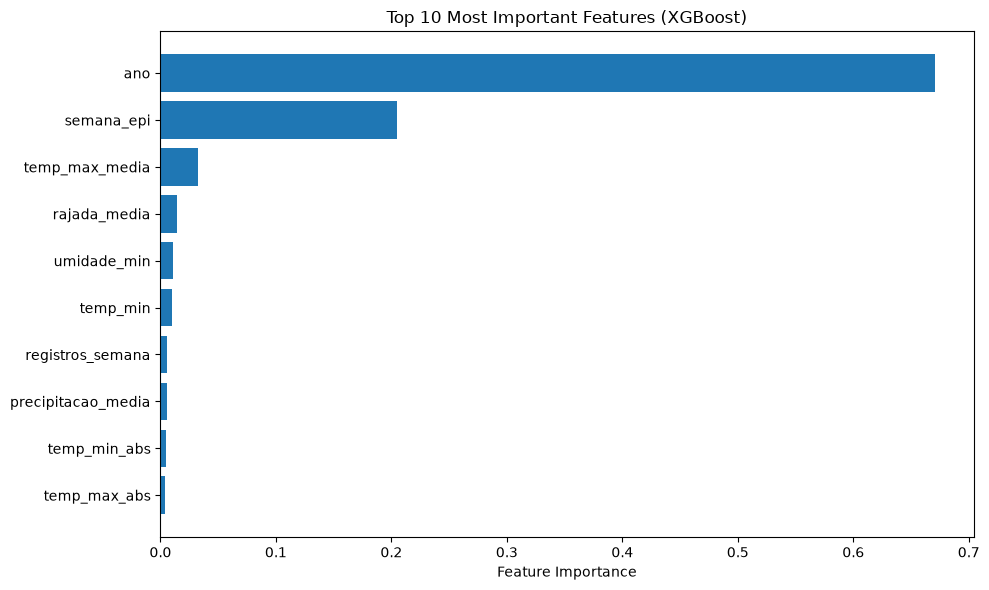


 Feature importance visualization displayed.


In [43]:
# Feature Importance
print("\n" + "="*60)
print("🔍 TOP 15 MOST IMPORTANT FEATURES")
print("="*60)

feature_importance = xgb_model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\n")
for idx, row in importance_df.head(15).iterrows():
    bar_length = int(row['Importance'] * 50)
    bar = '█' * bar_length
    print(f"{row['Feature']:30s} {bar} {row['Importance']:.4f}")

# Visualize top 10 features
plt.figure(figsize=(10, 6))
top_10_importance = importance_df.head(10)
plt.barh(range(len(top_10_importance)), top_10_importance['Importance'])
plt.yticks(range(len(top_10_importance)), top_10_importance['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n Feature importance visualization displayed.")


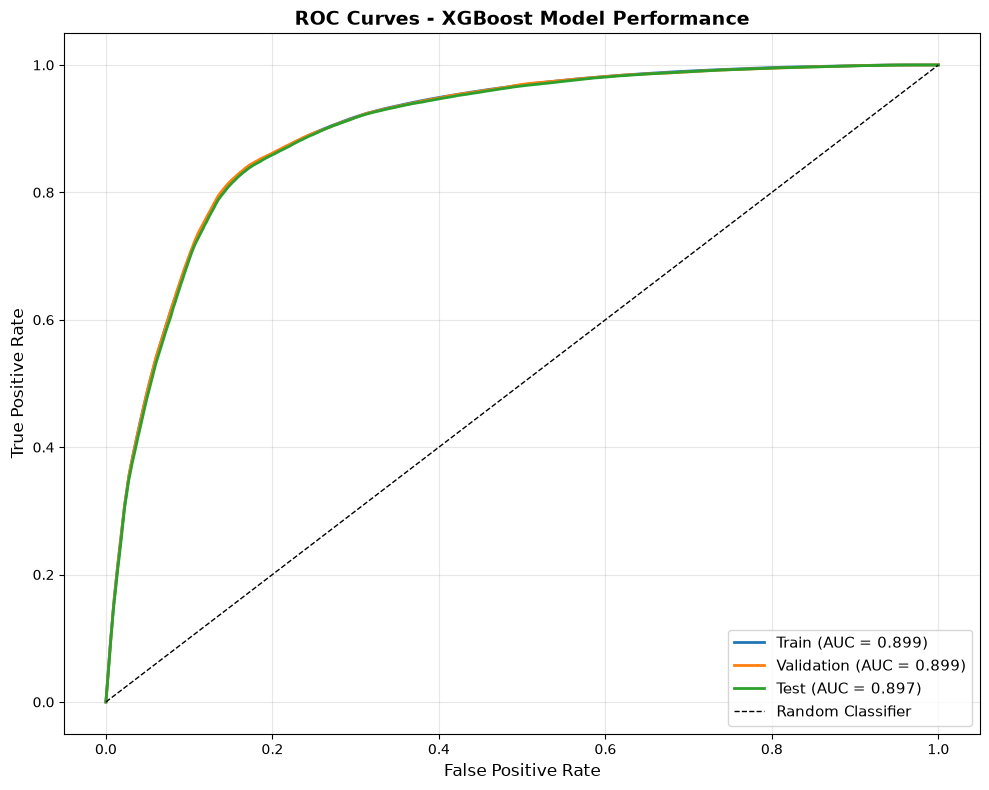

 ROC curves displayed.


In [44]:
# ROC Curves Comparison
plt.figure(figsize=(10, 8))

# Calculate ROC curves
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

# Plot ROC curves
plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {train_roc_auc:.3f})', linewidth=2)
plt.plot(fpr_val, tpr_val, label=f'Validation (AUC = {val_roc_auc:.3f})', linewidth=2)
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - XGBoost Model Performance', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(" ROC curves displayed.")


In [ ]:
# Save Model and Results
import pickle
from pathlib import Path

model_dir = Path('../data/processed/models')
model_dir.mkdir(parents=True, exist_ok=True)

# Save the trained model
model_path = model_dir / 'xgboost_dengue_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f" Model saved to: {model_path}")

# Save predictions
pred_results = pd.DataFrame({
    'y_test': y_test.values,
    'y_test_pred': y_test_pred,
    'y_test_pred_proba': y_test_pred_proba
})
pred_results_path = model_dir / 'xgboost_test_predictions.csv'
pred_results.to_csv(pred_results_path, index=False)
print(f" Test predictions saved to: {pred_results_path}")

# Summary Report
print("\n" + "="*60)
print(" FINAL SUMMARY - XGBOOST MODEL")
print("="*60)
print("\n Model Configuration:")
print("   - Estimators: 100")
print("   - Max Depth: 6")
print("   - Learning Rate: 0.1")
print("   - Subsample: 0.8")
print("   - Colsample_bytree: 0.8")

print("\n Test Set Performance:")
print(f"   - Accuracy:  {test_accuracy:.4f}")
print(f"   - Precision: {test_precision:.4f}")
print(f"   - Recall:    {test_recall:.4f}")
print(f"   - F1-Score:  {test_f1:.4f}")
print(f"   - ROC-AUC:   {test_roc_auc:.4f}")

print(f"\n Top Feature: {importance_df.iloc[0]['Feature']} (Importance: {importance_df.iloc[0]['Importance']:.4f})")
print("\n Ready for deployment!")


 Model saved to: ../data/processed/models/xgboost_dengue_model.pkl
 Test predictions saved to: ../data/processed/models/xgboost_test_predictions.csv

 FINAL SUMMARY - XGBOOST MODEL

 Model Configuration:
   - Estimators: 100
   - Max Depth: 6
   - Learning Rate: 0.1
   - Subsample: 0.8
   - Colsample_bytree: 0.8

 Test Set Performance:
   - Accuracy:  0.9177
   - Precision: 0.5714
   - Recall:    0.3039
   - F1-Score:  0.3968
   - ROC-AUC:   0.8973

 Top Feature: ano (Importance: 0.6707)

 Ready for deployment!


## 7. Evaluation

## 8. Results & Discussion

## 9. Limitations & Future Work